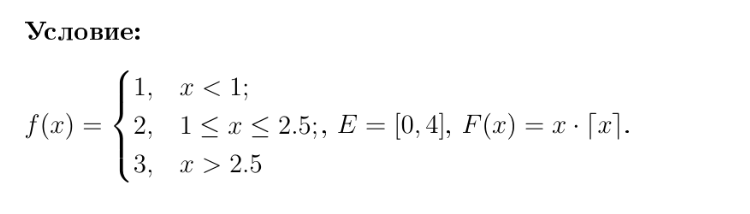


Для подсчетов численного метода написан класс разбивающий E на удобные рассматриваемые участки (аналогичные тем что использованы при подсчетах аналитического метода)

При вычислениях учитывается тип E_i и мера по которой берется интеграл

Для f:
∫ f dλ   = 8.5
∫ f dμ_F = 39.5
Для f_n:

n = 2
∫ f_n dλ   = 8.0
∫ f_n dμ_F = 35.0

n = 5
∫ f_n dλ   = 8.3
∫ f_n dμ_F = 38.9

n = 10
∫ f_n dλ   = 8.399999999999999
∫ f_n dμ_F = 39.2

n = 50
∫ f_n dλ   = 8.48
∫ f_n dμ_F = 39.44

n = 100
∫ f_n dλ   = 8.49
∫ f_n dμ_F = 39.47

графики f_n при нескольких значениях n (возрастающих)


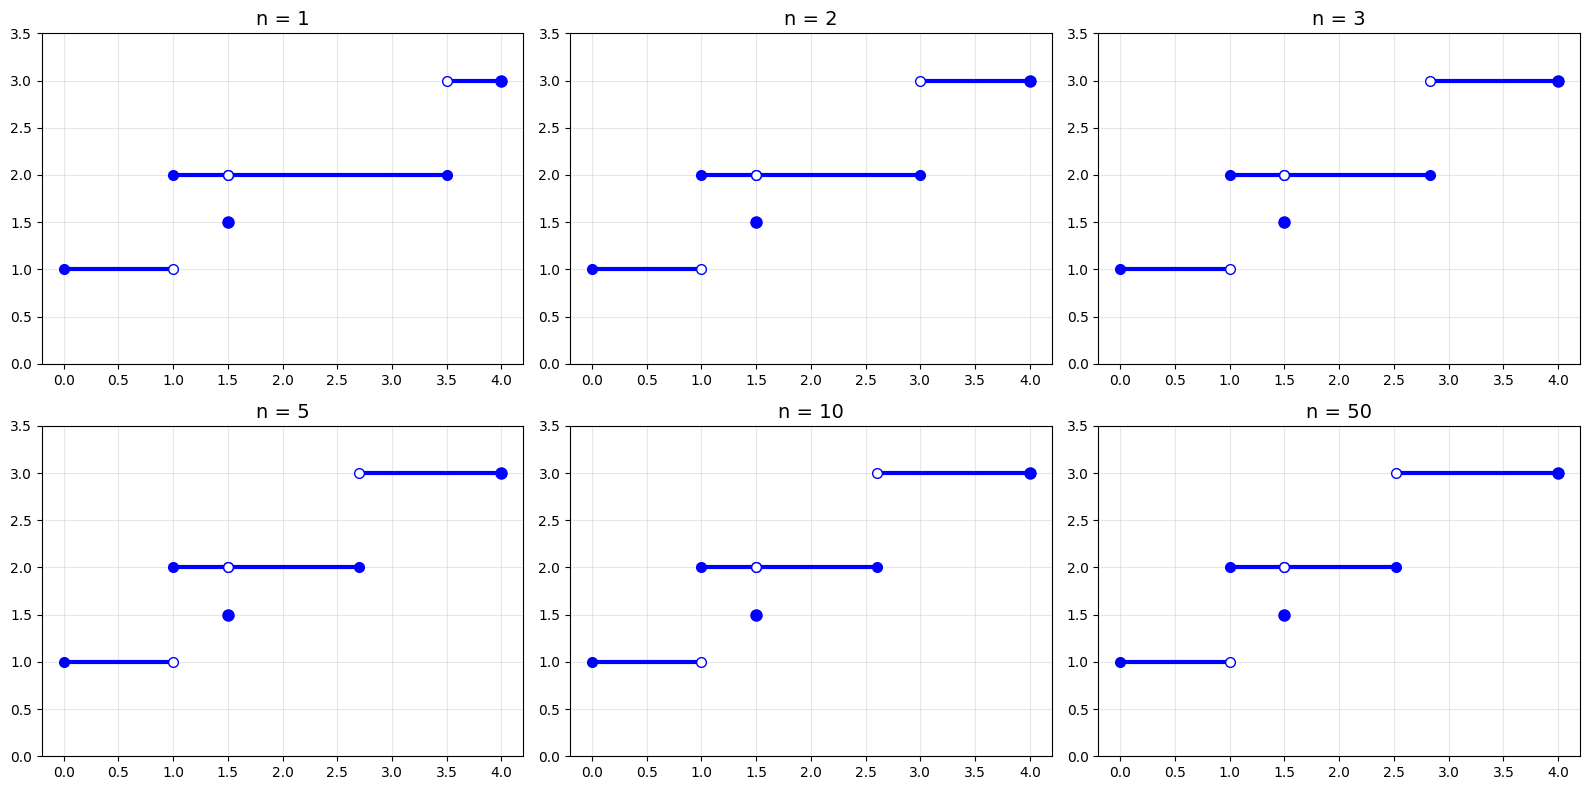


total time: 1.800914


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

start_time = time.time()

# F(x)
def F(x):
    return x * np.ceil(x)

# F(x + 0)
def F_right(x):
    if x >= 4: return 16.0
    # В целых точках справа ceil дает скачок
    if x == int(x) and x > 0:
        return x * (x + 1)
    return x * np.ceil(x)

class E_i:
    def __init__(self, val, a, b, interval_type):
        self.val = val
        self.a = a
        self.b = b
        self.interval_type = interval_type
        # '[)', '[]', '(]', '()', 'dot'

    # мера Лебега
    def mu_lebesgue(self):
        if self.interval_type == 'dot':
            return 0.0
        return max(0.0, self.b - self.a)

    # мера μ_F
    def mu_F(self):
        # [a,b)
        if self.interval_type == '[)': # f(b) - f(a)
            return F(self.b) - F(self.a)
        # [a,b]
        elif self.interval_type == '[]': # f(b+0) - f(a)
            return F_right(self.b) - F(self.a)
        # (a,b]
        elif self.interval_type == '(]': # f(b+0) - f(a+0)
            return F_right(self.b) - F_right(self.a)
        # (a,b)
        elif self.interval_type == '()': # f(b) - f(a+0)
            return F(self.b) - F_right(self.a)
        # {a}
        elif self.interval_type == 'dot': # точка - по сути как [] но пусть отдельным пунктиком
            return F_right(self.a) - F(self.a)
        return 0.0

# берем в зависимости от меры по которой интеграл
def integral(parts, measure='lebesgue'):
    if measure == 'lebesgue':
        return sum(p.val * p.mu_lebesgue() for p in parts)
    elif measure == 'muF':
        return sum(p.val * p.mu_F() for p in parts)

########## для f
Ei_s_for_f = [
    E_i(1.0, 0.0, 1.0, '[)'),   # [0, 1)
    E_i(2.0, 1.0, 2.5, '[]'),   # [1, 2.5]
    E_i(3.0, 2.5, 4.0, '(]')    # (2.5, 4]
]

I_f_L = integral(Ei_s_for_f, 'lebesgue')
I_f_muF = integral(Ei_s_for_f, 'muF')

print("Для f:")
print("∫ f dλ   =", I_f_L)
print("∫ f dμ_F =", I_f_muF)

########## для f_n
# задала как для конкретно взятых f_n бъется E для вычисления интегралов
def Ei_s_for_f_n(n):
    return [
        E_i(1.0, 0.0, 1.0, '[)'), # [0, 1)
        E_i(2.0, 1.0, 1.5, '[)'), # [1, 1.5)
        E_i(1.5, 1.5, 1.5, 'dot'), # {1.5}
        E_i(2.0, 1.5, 2.5 + 1/n, '(]'), # (1.5, 2.5 + 1/n]
        E_i(3.0, 2.5 + 1/n, 4.0, '()'), # (2.5 + 1/n; 4)
        E_i(3.0, 4.0, 4.0, 'dot') # {4}
    ]

print("Для f_n:")
for n in [2, 5, 10, 50, 100]:
    Ei_s_for_fn = Ei_s_for_f_n(n)
    I_L = integral(Ei_s_for_fn, 'lebesgue')
    I_muF = integral(Ei_s_for_fn, 'muF')
    print(f"\nn = {n}")
    print("∫ f_n dλ   =", I_L)
    print("∫ f_n dμ_F =", I_muF)
    
  
########### графички - f_n при увеличении n

# отрисовывается тоже по заданному разбиению на Ei - используя свои конструкции определяю какие интервалы
def draw_fn(ax, n):
    Ei_s = Ei_s_for_f_n(n)
    ax.set_xlim(-0.2, 4.2)
    ax.set_ylim(0, 3.5)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"n = {n}", fontsize=14)
    for Ei in Ei_s:
        if Ei.interval_type != 'dot':
            ax.plot([Ei.a, Ei.b], [Ei.val, Ei.val],
                    lw=3, color='blue')
        if Ei.interval_type in ['[)', '[]']:
            ax.plot(Ei.a, Ei.val, 'o',
                    color='blue', ms=7)
        if Ei.interval_type in ['()', '(]']:
            ax.plot(Ei.a, Ei.val, 'o',
                    markerfacecolor='white',
                    markeredgecolor='blue',
                    ms=7)
        if Ei.interval_type in ['[]', '(]']:
            ax.plot(Ei.b, Ei.val, 'o',
                    color='blue', ms=7)
        if Ei.interval_type in ['[)', '()']:
            ax.plot(Ei.b, Ei.val, 'o',
                    markerfacecolor='white',
                    markeredgecolor='blue',
                    ms=7)
        if Ei.interval_type == 'dot':
            ax.plot(Ei.a, Ei.val, 'o',
                    color='blue', ms=8)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

n_values = [1, 2, 3, 5, 10, 50, 100, 500]

print("\nграфики f_n при нескольких значениях n (возрастающих)")  
for ax, n in zip(axs.flat, n_values):
    draw_fn(ax, n)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"\ntotal time: {end_time - start_time:.6f}")

Мне досталась и так простая функция, которую можно было и оставить в качестве f_n = f
Но решила просто чуть ее изменить, сохранив сходимость почти всюду на E

Рассматриваемая функция F(x) является непрерывной слева - что учтено в функциях используемых для подсчетов в программе.

Для одинаковых подходов к подсчету - в численном и аналитическом - получены ожидаемые значения, при увеличении n 
∫ f_n dλ 
∫ f_n dμ_F
сходятся к аналогичным от f, что оправдывает полученное аналитическим методом выражение для значения интеграла, зависящее от n.

=========================================


аналогично были проделаны действия для модифицированной функции
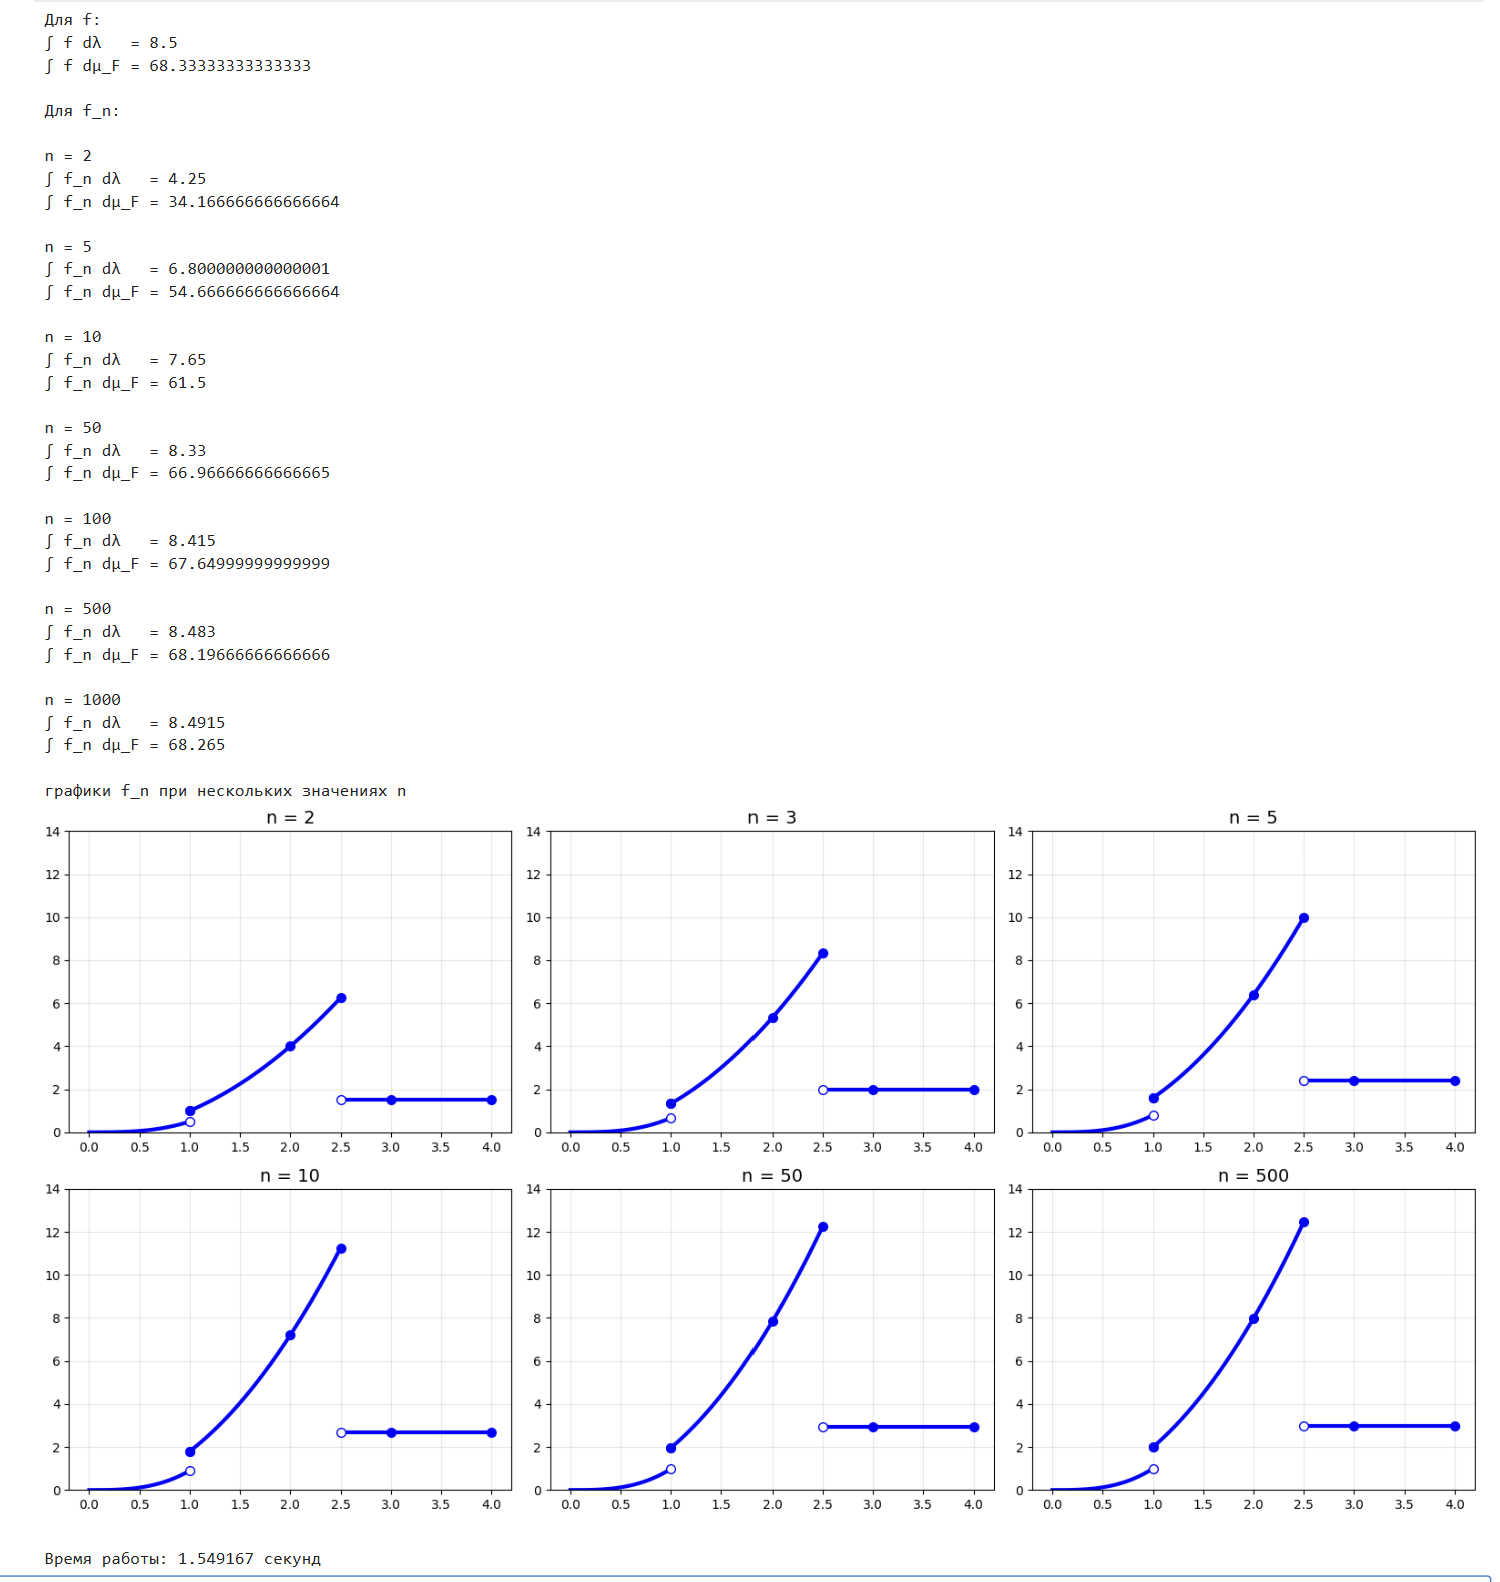

условие 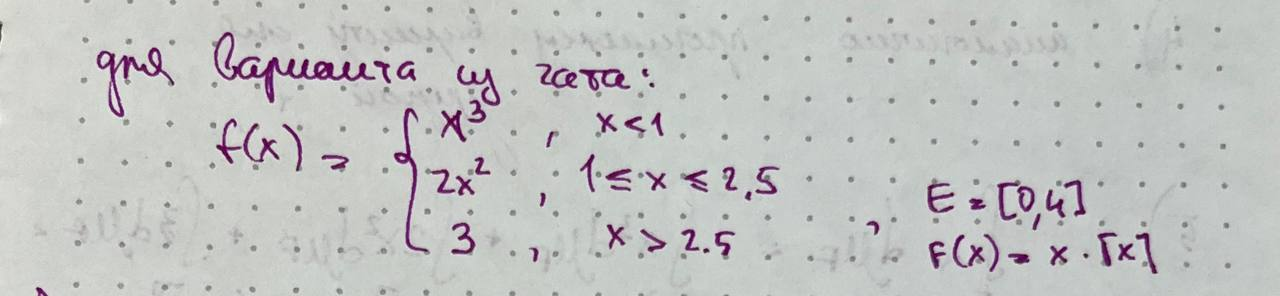